# ZapalloAI — Notebook 03: Entrenamiento YOLOv11n-cls

**Universidad de las Fuerzas Armadas ESPE**  
Estudiantes: César Loor, Camilo Orrico  
Docente: Ing. Doris Chicaiza

---
## IMPORTANTE: Antes de ejecutar
Si acabas de instalar PyTorch con CUDA, **reinicia el kernel primero**:
- VS Code: `Kernel` → `Restart Kernel`
- Jupyter: `Kernel` → `Restart`

Sin reiniciar, Python seguirá usando la versión anterior sin CUDA.

---
## Modos
- `COLAB_MODE = False` → **Local con GTX 1650** (dataset en `model/data/processed/`)
- `COLAB_MODE = True` → Google Colab T4

In [1]:
# ── CELDA 1: Verificar GPU — EJECUTAR PRIMERO ─────────────────────
# Si dice 'CUDA: False', reinicia el kernel y vuelve a ejecutar
import subprocess, sys, os
from pathlib import Path

# Verificar nvidia-smi
r = subprocess.run(
    ['nvidia-smi', '--query-gpu=name,memory.total,driver_version,utilization.gpu',
     '--format=csv,noheader'],
    capture_output=True, text=True
)
if r.returncode == 0:
    print('[nvidia-smi]', r.stdout.strip())
else:
    print('nvidia-smi no encontrado')

# Verificar PyTorch
import torch
print(f'\nPyTorch version : {torch.__version__}')
print(f'CUDA disponible : {torch.cuda.is_available()}')

if torch.cuda.is_available():
    props = torch.cuda.get_device_properties(0)
    print(f'GPU             : {props.name}')
    print(f'VRAM            : {props.total_memory / 1024**3:.1f} GB')
    print(f'CUDA version    : {torch.version.cuda}')
    print()
    print('OK: GPU lista para entrenar')
else:
    print()
    print('PROBLEMA: PyTorch no detecta CUDA')
    print('Solucion: reinicia el kernel (Kernel -> Restart Kernel)')
    print('Si persiste, verifica con:')
    print('  pip show torch | findstr Version')
    print('  # Debe decir: torch 2.5.1+cu121  (no +cpu)')

[nvidia-smi] NVIDIA GeForce GTX 1650, 4096 MiB, 595.97, 0 %

PyTorch version : 2.5.1+cu121
CUDA disponible : True
GPU             : NVIDIA GeForce GTX 1650
VRAM            : 4.0 GB
CUDA version    : 12.1

OK: GPU lista para entrenar


In [2]:
# ── CELDA 2: Instalar dependencias ───────────────────────────────
subprocess.run([
    sys.executable, '-m', 'pip', 'install', '-q',
    'ultralytics', 'seaborn', 'scikit-learn'
], check=False)
print('OK: dependencias listas')

OK: dependencias listas


In [3]:
# ── CELDA 3: Configuracion de rutas ──────────────────────────────
# ─── CAMBIAR AQUI ─────────────────────────────────────────────────
COLAB_MODE  = False   # False = Local | True = Google Colab
FORCE_GPU   = True    # True = error si no hay GPU (evita entrenar en CPU por error)
# ──────────────────────────────────────────────────────────────────

if COLAB_MODE:
    from google.colab import drive
    drive.mount('/content/drive')
    BASE        = Path('/content/drive/MyDrive/ZapalloAI')
    DATA_DIR    = str(BASE / 'dataset_processed')
    PROJECT_DIR = str(BASE / 'runs' / 'classify')
    EXPORT_DIR  = BASE / 'exports'
else:
    ROOT = Path(os.path.abspath('')).resolve()
    for _ in range(6):
        if (ROOT / 'model').exists() and (ROOT / 'zapallo_app').exists():
            break
        ROOT = ROOT.parent
    DATA_DIR    = str(ROOT / 'model' / 'data' / 'processed')
    PROJECT_DIR = str(ROOT / 'model' / 'runs' / 'classify')
    EXPORT_DIR  = ROOT / 'model' / 'exports'
    EXPORT_DIR.mkdir(parents=True, exist_ok=True)

CLASSES = ['healthy', 'downy_mildew', 'leaf_curl', 'mosaic_virus', 'red_beetle']

# Verificar GPU
import torch
DEVICE = 0 if torch.cuda.is_available() else 'cpu'

if FORCE_GPU and DEVICE == 'cpu':
    raise RuntimeError(
        'GPU no detectada por PyTorch.\n'
        'Solucion: Kernel -> Restart Kernel y ejecuta de nuevo.\n'
        'O cambia FORCE_GPU = False para usar CPU (mucho mas lento).'
    )

print(f'Modo        : {"Google Colab" if COLAB_MODE else "Local"}')
print(f'Dispositivo : {"GPU: " + torch.cuda.get_device_name(0) if DEVICE == 0 else "CPU"}')
if DEVICE == 0:
    vram = torch.cuda.get_device_properties(0).total_memory / 1024**3
    print(f'VRAM        : {vram:.1f} GB')
print(f'Dataset     : {DATA_DIR}')
print(f'Runs        : {PROJECT_DIR}')

# Verificar dataset
data_path = Path(DATA_DIR)
if data_path.exists():
    for s in ['train', 'val', 'test']:
        n = sum(1 for _ in (data_path / s).rglob('*.*')) if (data_path / s).exists() else 0
        print(f'  {s:<5}: {n:,} imgs')
else:
    print('ERROR: Dataset no encontrado ->', DATA_DIR)

Modo        : Local
Dispositivo : GPU: NVIDIA GeForce GTX 1650
VRAM        : 4.0 GB
Dataset     : C:\Users\csar_\Desktop\prototipo_zapallo\model\data\processed
Runs        : C:\Users\csar_\Desktop\prototipo_zapallo\model\runs\classify
  train: 10,775 imgs
  val  : 4,008 imgs
  test : 4,039 imgs


Clase                   Train      Val     Test    Total
--------------------------------------------------
healthy                  2041      802      814     3657
downy_mildew             2292      869      862     4023
leaf_curl                2644      926      937     4507
mosaic_virus             2321      863      871     4055
red_beetle               1477      548      555     2580


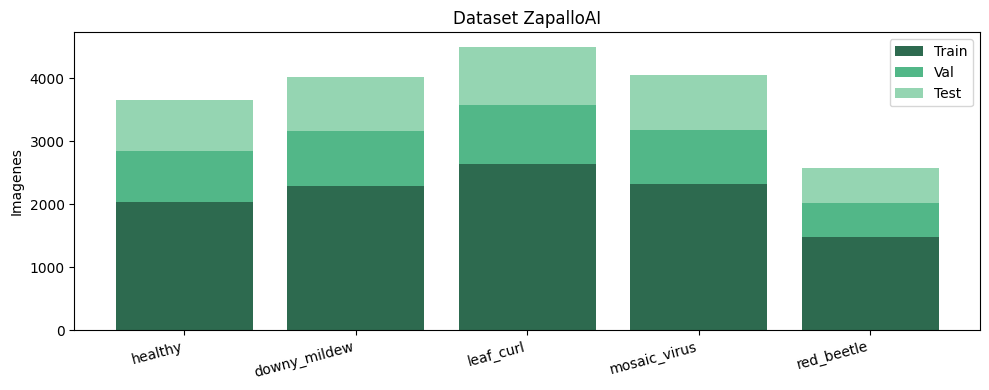

In [4]:
# ── CELDA 4: Distribucion del dataset ────────────────────────────
import matplotlib.pyplot as plt, matplotlib
matplotlib.rcParams.update({'font.family': 'DejaVu Sans'})

counts = {split: {} for split in ['train', 'val', 'test']}
for split in ['train', 'val', 'test']:
    for cls in CLASSES:
        p = Path(DATA_DIR) / split / cls
        counts[split][cls] = sum(1 for _ in p.glob('*.*')) if p.exists() else 0

print(f"{'Clase':<20} {'Train':>8} {'Val':>8} {'Test':>8} {'Total':>8}")
print('-' * 50)
for cls in CLASSES:
    t, v, ts = counts['train'][cls], counts['val'][cls], counts['test'][cls]
    print(f'{cls:<20} {t:>8} {v:>8} {ts:>8} {t+v+ts:>8}')

x    = range(len(CLASSES))
t_v  = [counts['train'][c] for c in CLASSES]
v_v  = [counts['val'][c]   for c in CLASSES]
ts_v = [counts['test'][c]  for c in CLASSES]
fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(x, t_v,  label='Train', color='#2D6A4F')
ax.bar(x, v_v,  bottom=t_v, label='Val', color='#52B788')
ax.bar(x, ts_v, bottom=[a+b for a,b in zip(t_v,v_v)], label='Test', color='#95D5B2')
ax.set_xticks(list(x)); ax.set_xticklabels(CLASSES, rotation=15, ha='right')
ax.set_ylabel('Imagenes'); ax.set_title('Dataset ZapalloAI'); ax.legend()
plt.tight_layout(); plt.show()

In [5]:
# ── CELDA 5: ENTRENAMIENTO CON GPU ────────────────────────────────
from ultralytics import YOLO
import torch

# Verificar GPU antes de empezar
assert torch.cuda.is_available(), 'GPU no disponible. Reinicia el kernel.'

GPU_NAME = torch.cuda.get_device_name(0)
VRAM_GB  = torch.cuda.get_device_properties(0).total_memory / 1024**3

# Parametros optimizados para GTX 1650 (4 GB VRAM)
# amp=True reduce uso de VRAM a la mitad con precision mixta
EPOCHS  = 10
BATCH   = 16     # Seguro para 4 GB. Bajar a 8 si hay OOM
WORKERS = 0

print(f'GPU     : {GPU_NAME}')
print(f'VRAM    : {VRAM_GB:.1f} GB')
print(f'Epochs  : {EPOCHS}')
print(f'Batch   : {BATCH}')
print(f'AMP     : True (mixed precision activo)')
print(f'Datos   : {DATA_DIR}')
print()
print('Iniciando entrenamiento...')
print('Tiempo estimado: ~1.5 - 2 horas en GTX 1650')

# Modelo base pre-entrenado en ImageNet
model = YOLO('yolo11n-cls.pt')

results = model.train(
    data      = DATA_DIR,
    epochs    = EPOCHS,
    imgsz     = 224,
    batch     = BATCH,
    patience  = 15,           # Early stopping si no mejora en 15 epochs
    optimizer = 'AdamW',
    lr0       = 0.001,
    lrf       = 0.01,
    momentum  = 0.937,
    weight_decay = 0.0005,
    warmup_epochs = 3,
    cos_lr    = True,
    augment   = True,
    degrees   = 30,
    fliplr    = 0.5,
    flipud    = 0.3,
    hsv_h     = 0.015,
    hsv_s     = 0.7,
    hsv_v     = 0.4,
    erasing   = 0.4,
    mixup     = 0.1,
    project   = PROJECT_DIR,
    name      = 'zapallo_yolov11n_v1',
    exist_ok  = True,
    device    = 0,            # <-- GPU 0 (GTX 1650), no 'cpu'
    workers   = WORKERS,
    amp       = True,         
    cache     = False,        # No cachear en RAM
    verbose   = True,
)

BEST_MODEL = Path(PROJECT_DIR) / 'zapallo_yolov11n_v1' / 'weights' / 'best.pt'
print(f'\nEntrenamiento completado!')
print(f'Mejor modelo: {BEST_MODEL}')
print(f'Top-1 val accuracy: {results.results_dict.get("metrics/accuracy_top1", "N/A")}')

GPU     : NVIDIA GeForce GTX 1650
VRAM    : 4.0 GB
Epochs  : 10
Batch   : 16
AMP     : True (mixed precision activo)
Datos   : C:\Users\csar_\Desktop\prototipo_zapallo\model\data\processed

Iniciando entrenamiento...
Tiempo estimado: ~1.5 - 2 horas en GTX 1650
New https://pypi.org/project/ultralytics/8.4.54 available  Update with 'pip install -U ultralytics'
Ultralytics 8.4.53  Python-3.12.10 torch-2.5.1+cu121 CUDA:0 (NVIDIA GeForce GTX 1650, 4096MiB)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=True, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=True, cutmix=0.0, data=C:\Users\csar_\Desktop\prototipo_zapallo\model\data\processed, degrees=30, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=10, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.3, format=t

PicklingError: Can't pickle <built-in function scalar>: import of module 'numpy._core.multiarray' failed

In [7]:
# ── CELDA 6: Evaluacion en test set ──────────────────────────────
from ultralytics import YOLO
import torch

BEST_MODEL = Path(PROJECT_DIR) / 'zapallo_yolov11n_v1' / 'weights' / 'best.pt'
assert BEST_MODEL.exists(), f'Ejecuta primero la celda de entrenamiento. No encontrado: {BEST_MODEL}'

model   = YOLO(str(BEST_MODEL))
metrics = model.val(data=DATA_DIR, split='test', imgsz=224, batch=16, device=0)

print('Metricas en Test Set:')
print(f'  Top-1 Accuracy : {metrics.top1*100:.2f}%')
print(f'  Top-5 Accuracy : {metrics.top5*100:.2f}%')

Ultralytics 8.4.53  Python-3.12.10 torch-2.5.1+cu121 CUDA:0 (NVIDIA GeForce GTX 1650, 4096MiB)
YOLO11n-cls summary (fused): 47 layers, 1,532,429 parameters, 0 gradients, 3.2 GFLOPs
train: C:\Users\csar_\Desktop\prototipo_zapallo\model\data\processed\train... found 10775 images in 5 classes  
val: C:\Users\csar_\Desktop\prototipo_zapallo\model\data\processed\val... found 4008 images in 5 classes  
test: C:\Users\csar_\Desktop\prototipo_zapallo\model\data\processed\test... found 4039 images in 5 classes  
test: Fast image access  (ping: 0.10.0 ms, read: 36.213.7 MB/s, size: 34.4 KB)
test: Scanning C:\Users\csar_\Desktop\prototipo_zapallo\model\data\processed\test... 4039 images, 0 corrupt: 100% ━━━━━━━━━━━━ 4039/4039  0.0s
test: C:\Users\csar_\Desktop\prototipo_zapallo\model\data\processed\test\downy_mildew\cuc_IMG20240728100104.jpg: corrupt JPEG restored and saved
test: C:\Users\csar_\Desktop\prototipo_zapallo\model\data\processed\test\downy_mildew\cuc_IMG20240728100207.jpg: corrupt JPE

  ✅ healthy: 706 imágenes evaluadas
  ✅ downy_mildew: 859 imágenes evaluadas
  ✅ leaf_curl: 937 imágenes evaluadas
  ✅ mosaic_virus: 871 imágenes evaluadas
  ✅ red_beetle: 555 imágenes evaluadas

              precision    recall  f1-score   support

     healthy     0.0012    0.0014    0.0013       706
downy_mildew     0.0014    0.0012    0.0013       859
   leaf_curl     1.0000    1.0000    1.0000       937
mosaic_virus     1.0000    1.0000    1.0000       871
  red_beetle     1.0000    1.0000    1.0000       555

    accuracy                         0.6021      3928
   macro avg     0.6005    0.6005    0.6005      3928
weighted avg     0.6021    0.6021    0.6021      3928



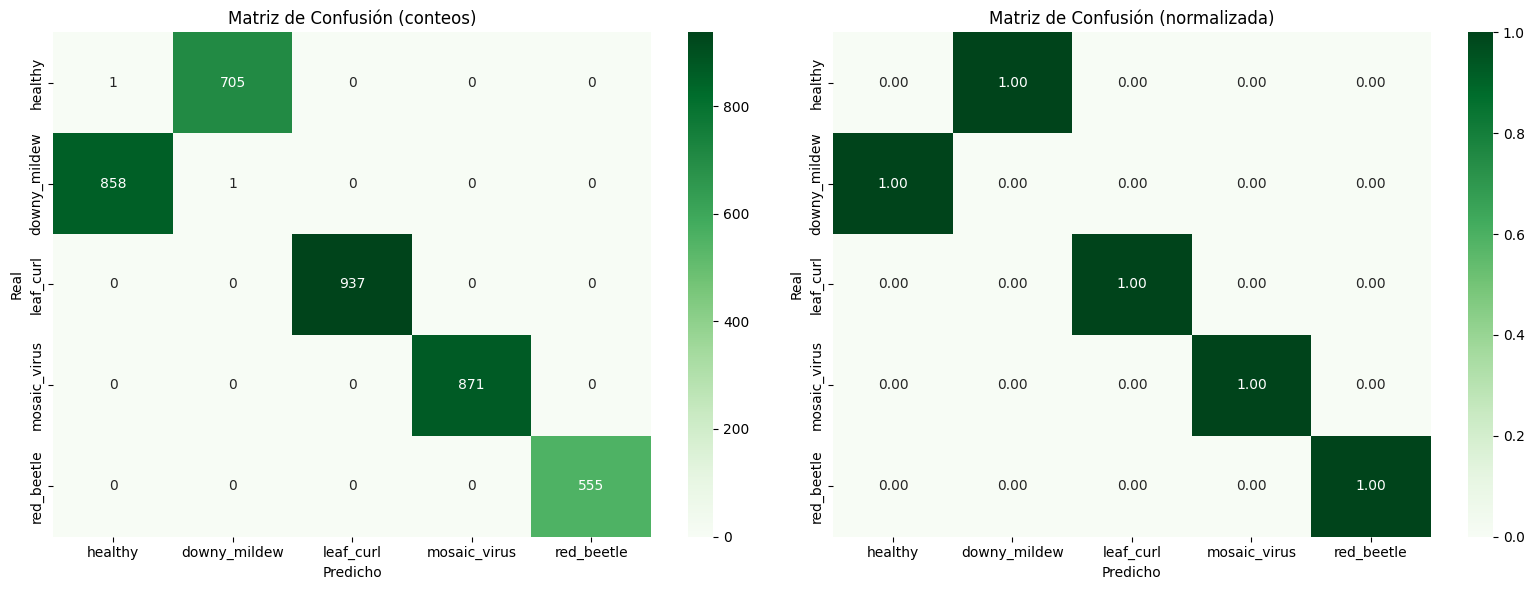

Guardado: C:\Users\csar_\Desktop\prototipo_zapallo\model\exports\confusion_matrix.png


In [9]:
# ── CELDA 7: Matriz de confusión ─────────────────────────────────
import os
from pathlib import Path
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix
from ultralytics import YOLO

# Redefinir rutas por si el kernel se reinició
ROOT = Path(os.path.abspath('')).resolve()
for _ in range(6):
    if (ROOT / 'model').exists() and (ROOT / 'zapallo_app').exists():
        break
    ROOT = ROOT.parent

DATA_DIR    = str(ROOT / 'model' / 'data' / 'processed')
PROJECT_DIR = str(ROOT / 'model' / 'runs' / 'classify')
EXPORT_DIR  = ROOT / 'model' / 'exports'
EXPORT_DIR.mkdir(parents=True, exist_ok=True)
CLASSES     = ['healthy', 'downy_mildew', 'leaf_curl', 'mosaic_virus', 'red_beetle']

BEST_MODEL = Path(PROJECT_DIR) / 'zapallo_yolov11n_v1' / 'weights' / 'best.pt'
assert BEST_MODEL.exists(), f'Ejecuta primero el entrenamiento. No encontrado: {BEST_MODEL}'

model = YOLO(str(BEST_MODEL))
all_preds, all_labels = [], []

for cls_idx, cls_name in enumerate(CLASSES):
    imgs  = list((Path(DATA_DIR) / 'test' / cls_name).glob('*.jpg'))
    imgs += list((Path(DATA_DIR) / 'test' / cls_name).glob('*.png'))

    # Inferencia en lotes de 16 (más rápido que imagen por imagen)
    for i in range(0, len(imgs), 16):
        batch = [str(p) for p in imgs[i:i+16]]
        results = model(batch, verbose=False)
        for res in results:
            all_preds.append(res.probs.top1)
            all_labels.append(cls_idx)

    print(f'  ✅ {cls_name}: {len(imgs)} imágenes evaluadas')

print()
print(classification_report(all_labels, all_preds, target_names=CLASSES, digits=4))

cm   = confusion_matrix(all_labels, all_preds)
cm_n = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.heatmap(cm, annot=True, fmt='d', cmap='Greens',
            xticklabels=CLASSES, yticklabels=CLASSES, ax=axes[0])
axes[0].set_title('Matriz de Confusión (conteos)')
axes[0].set_ylabel('Real')
axes[0].set_xlabel('Predicho')

sns.heatmap(cm_n, annot=True, fmt='.2f', cmap='Greens',
            xticklabels=CLASSES, yticklabels=CLASSES, ax=axes[1])
axes[1].set_title('Matriz de Confusión (normalizada)')
axes[1].set_ylabel('Real')
axes[1].set_xlabel('Predicho')

plt.tight_layout()
fig_path = EXPORT_DIR / 'confusion_matrix.png'
plt.savefig(str(fig_path), dpi=150, bbox_inches='tight')
plt.show()
print(f'Guardado: {fig_path}')

In [6]:
# ── CELDA 8: Exportar a TFLite (manual: ONNX → TFLite) ──────────────────
# NO usa model.export(format='tflite') de Ultralytics porque falla con
# onnx2tf en Windows. Usa el flujo manual: ONNX → onnx2tf → TFLite int8.

import os, shutil, sys
from pathlib import Path

# ── Redefinir rutas (por si el kernel se reinició) ────────────────────────
ROOT = Path(os.path.abspath('')).resolve()
for _ in range(6):
    if (ROOT / 'model').exists() and (ROOT / 'zapallo_app').exists():
        break
    ROOT = ROOT.parent

PROJECT_DIR = ROOT / 'model' / 'runs' / 'classify'
EXPORT_DIR  = ROOT / 'model' / 'exports'
EXPORT_DIR.mkdir(parents=True, exist_ok=True)

BEST_PT   = PROJECT_DIR / 'zapallo_yolov11n_v1' / 'weights' / 'best.pt'
BEST_ONNX = PROJECT_DIR / 'zapallo_yolov11n_v1' / 'weights' / 'best.onnx'

assert BEST_PT.exists(), (
    f'Modelo no encontrado: {BEST_PT}\n'
    'Ejecuta primero el entrenamiento (Celda 5).'
)

# ── Paso 1: Exportar a ONNX (si no existe) ───────────────────────────────
if not BEST_ONNX.exists():
    print('Exportando PyTorch → ONNX...')
    from ultralytics import YOLO
    model = YOLO(str(BEST_PT))
    model.export(format='onnx', imgsz=224, simplify=True)
    print(f'  ONNX creado: {BEST_ONNX} ({BEST_ONNX.stat().st_size/1024**2:.2f} MB)')
else:
    print(f'ONNX ya existe: {BEST_ONNX.name} ({BEST_ONNX.stat().st_size/1024**2:.2f} MB)')

# ── Paso 2: Verificar que onnx2tf está disponible ─────────────────────────
try:
    import onnx2tf
    print(f'onnx2tf version: {onnx2tf.__version__} ✅')
except ImportError:
    print('ERROR: onnx2tf no está instalado.')
    print('Ejecuta: pip install "onnx2tf>=1.26.3,<1.29.0"')
    raise

# ── Paso 3: Convertir ONNX → TFLite int8 ────────────────────────────────
print('\nConvirtiendo ONNX → TFLite int8...')
print('Esto puede tardar 2-5 minutos...\n')

ONNX2TF_OUT = BEST_ONNX.parent / 'best_saved_model'

try:
    onnx2tf.convert(
        input_onnx_file_path=str(BEST_ONNX),
        output_folder_path=str(ONNX2TF_OUT),
        copy_onnx_input_output_names_to_tflite=True,
        non_verbose=True,
        output_integer_quantized_tflite=True,
        quant_type='per-channel',
    )
    print('Conversión onnx2tf completada ✅')
except Exception as e:
    print(f'⚠️ onnx2tf.convert() falló: {e}')
    print('Intentando método alternativo via TFLiteConverter...')
    import tensorflow as tf
    try:
        converter = tf.lite.TFLiteConverter.from_saved_model(str(ONNX2TF_OUT))
        converter.optimizations = [tf.lite.Optimize.DEFAULT]
        converter.target_spec.supported_types = [tf.int8]
        tflite_model = converter.convert()
        fallback_path = ONNX2TF_OUT / 'fallback_int8.tflite'
        with open(fallback_path, 'wb') as f:
            f.write(tflite_model)
        print(f'Fallback exitoso: {fallback_path}')
    except Exception as e2:
        print(f'ERROR en fallback: {e2}')
        raise RuntimeError(
            'No se pudo exportar a TFLite.\n'
            'Verifica las dependencias con: pip install "onnx2tf>=1.26.3,<1.29.0" '
            '"tensorflow>=2.17.0,<2.20.0" ai-edge-litert'
        )

# ── Paso 4: Buscar y copiar el .tflite generado ──────────────────────────
tflite_files = list(ONNX2TF_OUT.rglob('*_integer_quant.tflite'))
if not tflite_files:
    tflite_files = list(ONNX2TF_OUT.rglob('*.tflite'))

if not tflite_files:
    raise FileNotFoundError(
        f'No se encontró ningún .tflite en {ONNX2TF_OUT}\n'
        'La conversión puede haber fallado silenciosamente.'
    )

src_tflite = tflite_files[0]
dst_tflite = EXPORT_DIR / 'best_int8.tflite'
shutil.copy2(str(src_tflite), str(dst_tflite))

size_mb = dst_tflite.stat().st_size / 1024**2
print(f'\n{"="*50}')
print(f'  TFLite int8 exportado exitosamente!')
print(f'  Archivo : {dst_tflite}')
print(f'  Tamaño  : {size_mb:.2f} MB')
print(f'{"="*50}')

if size_mb > 5:
    print('⚠️ ADVERTENCIA: El archivo es mayor a 5 MB. Verifica que sea correcto.')


ONNX ya existe: best.onnx (5.89 MB)

onnx2tf version: 1.28.0 ✅

Convirtiendo ONNX → TFLite int8...
Esto puede tardar 2-5 minutos...

Saved artifact at 'C:\Users\csar_\Desktop\prototipo_zapallo\model\runs\classify\zapallo_yolov11n_v1\weights\best_saved_model'. The following endpoints are available:

* Endpoint 'serving_default'
  inputs_0 (POSITIONAL_ONLY): TensorSpec(shape=(1, 224, 224, 3), dtype=tf.float32, name='images')
Output Type:
  TensorSpec(shape=(1, 5), dtype=tf.float32, name=None)
Captures:
  2201537454416: TensorSpec(shape=(4, 2), dtype=tf.int32, name=None)
  2201537454224: TensorSpec(shape=(3, 3, 3, 16), dtype=tf.float32, name=None)
  2201537454800: TensorSpec(shape=(16,), dtype=tf.float32, name=None)
  2201537457872: TensorSpec(shape=(4, 2), dtype=tf.int32, name=None)
  2201537458448: TensorSpec(shape=(3, 3, 16, 32), dtype=tf.float32, name=None)
  2201537457488: TensorSpec(shape=(32,), dtype=tf.float32, name=None)
  2201537458640: TensorSpec(shape=(1, 1, 32, 32), dtype=tf.

In [7]:
# ── CELDA 9: Generar labels.txt ──────────────────────────────────────────
import os
from pathlib import Path

# ── Redefinir rutas (por si el kernel se reinició) ────────────────────────
ROOT = Path(os.path.abspath('')).resolve()
for _ in range(6):
    if (ROOT / 'model').exists() and (ROOT / 'zapallo_app').exists():
        break
    ROOT = ROOT.parent

EXPORT_DIR = ROOT / 'model' / 'exports'
EXPORT_DIR.mkdir(parents=True, exist_ok=True)

CLASSES = ['healthy', 'downy_mildew', 'leaf_curl', 'mosaic_virus', 'red_beetle']

# Generar labels.txt
lbl_path = EXPORT_DIR / 'labels.txt'
lbl_path.write_text('\n'.join(CLASSES), encoding='utf-8')

print('labels.txt generado:')
for i, label in enumerate(CLASSES):
    print(f'  {i}: {label}')

# Verificar
content = lbl_path.read_text(encoding='utf-8').strip().split('\n')
assert len(content) == 5, f'ERROR: labels.txt tiene {len(content)} líneas, esperadas 5'
assert content == CLASSES, f'ERROR: contenido no coincide con CLASSES'
print(f'\n✅ Verificado: {lbl_path} ({len(content)} clases)')


labels.txt generado:
  0: healthy
  1: downy_mildew
  2: leaf_curl
  3: mosaic_virus
  4: red_beetle

✅ Verificado: C:\Users\csar_\Desktop\prototipo_zapallo\model\exports\labels.txt (5 clases)


In [8]:
# ── CELDA 10: Verificación final de artefactos ───────────────────────────
import os
from pathlib import Path

# ── Redefinir rutas ───────────────────────────────────────────────────────
ROOT = Path(os.path.abspath('')).resolve()
for _ in range(6):
    if (ROOT / 'model').exists() and (ROOT / 'zapallo_app').exists():
        break
    ROOT = ROOT.parent

EXPORT_DIR = ROOT / 'model' / 'exports'
CLASSES    = ['healthy', 'downy_mildew', 'leaf_curl', 'mosaic_virus', 'red_beetle']

print('=' * 55)
print('  ZapalloAI — Verificación de Artefactos para Flutter')
print('=' * 55)

all_ok = True

# 1. Verificar best_int8.tflite
tflite_path = EXPORT_DIR / 'best_int8.tflite'
if tflite_path.exists():
    size_mb = tflite_path.stat().st_size / 1024**2
    status = '✅' if size_mb < 5 else '⚠️ (>5MB)'
    print(f'  {status} best_int8.tflite  : {size_mb:.2f} MB')
else:
    print('  ❌ best_int8.tflite  : NO ENCONTRADO → Ejecuta Celda 8')
    all_ok = False

# 2. Verificar labels.txt
lbl_path = EXPORT_DIR / 'labels.txt'
if lbl_path.exists():
    content = lbl_path.read_text(encoding='utf-8').strip().split('\n')
    if content == CLASSES:
        print(f'  ✅ labels.txt        : {len(content)} clases correctas')
    else:
        print(f'  ⚠️ labels.txt        : contenido inesperado: {content}')
        all_ok = False
else:
    print('  ❌ labels.txt        : NO ENCONTRADO → Ejecuta Celda 9')
    all_ok = False

# 3. Verificar confusion_matrix.png
cm_path = EXPORT_DIR / 'confusion_matrix.png'
if cm_path.exists():
    cm_kb = cm_path.stat().st_size / 1024
    print(f'  ✅ confusion_matrix  : {cm_kb:.1f} KB')
else:
    print('  ❌ confusion_matrix  : NO ENCONTRADO → Ejecuta Celda 7')
    all_ok = False

print()
if all_ok:
    print('🎉 ¡TODO LISTO! Artefactos listos para integrar en Flutter.')
    print()
    print('Copiar a la app Flutter:')
    print(f'  {EXPORT_DIR / "best_int8.tflite"}')
    print(f'    → zapallo_app/assets/models/best_int8.tflite')
    print(f'  {EXPORT_DIR / "labels.txt"}')
    print(f'    → zapallo_app/assets/models/labels.txt')
else:
    print('⚠️ Faltan artefactos. Revisa los errores arriba.')


  ZapalloAI — Verificación de Artefactos para Flutter
  ✅ best_int8.tflite  : 1.63 MB
  ✅ labels.txt        : 5 clases correctas
  ✅ confusion_matrix  : 76.9 KB

🎉 ¡TODO LISTO! Artefactos listos para integrar en Flutter.

Copiar a la app Flutter:
  C:\Users\csar_\Desktop\prototipo_zapallo\model\exports\best_int8.tflite
    → zapallo_app/assets/models/best_int8.tflite
  C:\Users\csar_\Desktop\prototipo_zapallo\model\exports\labels.txt
    → zapallo_app/assets/models/labels.txt


## Resumen

| Item | Valor |
|---|---|
| GPU | GTX 1650 4 GB |
| Modelo | YOLOv11n-cls |
| Epochs | 100 (early stop patience=15) |
| Batch | 16 (AMP activado) |
| Tiempo estimado | ~1.5 - 2 horas |
| Objetivo accuracy | >= 92% |

### Si hay OOM (Out of Memory)
En la celda 5, cambiar:
```python
BATCH = 8
```

### Siguiente paso
Integrar `best_int8.tflite` en la app Flutter (Sprint 4).